# MountainCar-v0 with Semi-Gradient SARSA and Tile Coding



In [14]:
# Core imports
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Iterable, Optional, Sequence, Tuple, Dict, List

np.set_printoptions(precision=4, suppress=True)

print("NumPy:", np.__version__)
print("Gymnasium:", gym.__version__)

NumPy: 2.4.2
Gymnasium: 1.2.3


## 1. Why MountainCar is hard for tabular methods

MountainCar has a continuous state space: position is in `[-1.2, 0.6]` and velocity is in `[-0.07, 0.07]`. A tabular method would need one entry for every possible real-valued state, which is impossible because there are infinitely many states.

A crude discretization could turn the space into bins, but a single hard grid loses smoothness. Two nearly identical states can fall into different bins and receive unrelated values. Tile coding fixes this by using several overlapping grids. Each state activates one tile in each tiling, giving a sparse binary feature representation. Then semi-gradient SARSA learns a linear action-value function:

\[
\hat{q}(s,a,\mathbf{w}) = \mathbf{w}_a^\top \mathbf{x}(s)
\]

where each action has its own weight vector and \(\mathbf{x}(s)\) is the tile-coded feature vector.

In [15]:
@dataclass
class TileCoder:
    """
    Tile coding feature constructor for continuous state spaces.

    Parameters
    ----------
    low, high:
        Lower and upper bounds for each state dimension.
    num_tilings:
        Number of overlapping tilings.
    tiles_per_dim:
        Number of tiles along each state dimension, e.g. (8, 8).
    offset_mode:
        'diagonal' gives deterministic staggered offsets.
        'random' gives reproducible random offsets if seed is provided.
    seed:
        Random seed used only for offset_mode='random'.

    Returns
    -------
    active_tiles(state):
        List of active feature indices, one per tiling.
    features(state):
        Dense sparse-binary vector. Useful for showing dot product directly.
    """

    low: Sequence[float]
    high: Sequence[float]
    num_tilings: int = 8
    tiles_per_dim: Sequence[int] = (8, 8)
    offset_mode: str = "diagonal"
    seed: Optional[int] = None

    def __post_init__(self):
        self.low = np.asarray(self.low, dtype=float)
        self.high = np.asarray(self.high, dtype=float)
        self.tiles_per_dim = np.asarray(self.tiles_per_dim, dtype=int)

        assert self.low.shape == self.high.shape
        assert len(self.tiles_per_dim) == len(self.low)
        assert self.num_tilings > 0
        assert np.all(self.tiles_per_dim > 0)

        self.n_dims = len(self.low)
        self.tile_width = (self.high - self.low) / self.tiles_per_dim
        self.tiles_per_tiling = int(np.prod(self.tiles_per_dim))
        self.num_features = self.num_tilings * self.tiles_per_tiling

        self.offsets = self._make_offsets()

    def _make_offsets(self) -> np.ndarray:
        """Create one offset vector per tiling."""
        if self.offset_mode == "diagonal":
            # Stagger each tiling by a fraction of one tile width.
            # The multiplier (d + 1) avoids perfectly identical shifts in each dimension.
            offsets = []
            for t in range(self.num_tilings):
                frac = t / self.num_tilings
                dim_offsets = frac * self.tile_width * (np.arange(self.n_dims) + 1) / self.n_dims
                offsets.append(dim_offsets)
            return np.asarray(offsets)

        if self.offset_mode == "random":
            rng = np.random.default_rng(self.seed)
            return rng.uniform(0.0, self.tile_width, size=(self.num_tilings, self.n_dims))

        raise ValueError("offset_mode must be either 'diagonal' or 'random'")

    def active_tiles(self, state: Sequence[float]) -> List[int]:
        """Return active tile indices. Exactly one tile is active per tiling."""
        state = np.asarray(state, dtype=float)
        active = []

        for tiling_id in range(self.num_tilings):
            shifted = state - self.low + self.offsets[tiling_id]
            coords = np.floor(shifted / self.tile_width).astype(int)
            coords = np.clip(coords, 0, self.tiles_per_dim - 1)

            flat_tile = np.ravel_multi_index(tuple(coords), tuple(self.tiles_per_dim))
            active.append(tiling_id * self.tiles_per_tiling + int(flat_tile))

        return active

    def features(self, state: Sequence[float]) -> np.ndarray:
        """Return dense sparse-binary vector x(s)."""
        x = np.zeros(self.num_features, dtype=float)
        x[self.active_tiles(state)] = 1.0
        return x


# Sanity check using MountainCar bounds
env = gym.make("MountainCar-v0")
tc = TileCoder(
    low=env.observation_space.low,
    high=env.observation_space.high,
    num_tilings=8,
    tiles_per_dim=(8, 8),
)
test_state = np.array([-0.5, 0.02])
active = tc.active_tiles(test_state)
x = tc.features(test_state)

print("Observation low:", env.observation_space.low)
print("Observation high:", env.observation_space.high)
print("Total features:", tc.num_features)
print("Active indices:", active)
print("Active count:", int(x.sum()), "should equal num_tilings =", tc.num_tilings)
env.close()

Observation low: [-1.2  -0.07]
Observation high: [0.6  0.07]
Total features: 512
Active indices: [29, 93, 157, 221, 285, 349, 413, 478]
Active count: 8 should equal num_tilings = 8


## 2. Semi-gradient SARSA with one weight vector per action

For MountainCar, the action space has three actions:

- `0`: push left  
- `1`: no push  
- `2`: push right  

The action-value estimate is computed as a linear function. Because the feature vector is sparse, the implementation computes the dot product efficiently by summing the active weights:

\[
Q(s,a) = \sum_{i \in \text{active}(s)} w_{a,i}
\]

This is equivalent to `np.dot(weights[a], features)` but faster because only `num_tilings` features are active.

In [16]:
def q_value(weights: np.ndarray, active: Sequence[int], action: int) -> float:
    """Q(s,a) using sparse active tile indices."""
    return float(weights[action, active].sum())


def q_values(weights: np.ndarray, active: Sequence[int]) -> np.ndarray:
    """Compute Q-values for all actions."""
    return weights[:, active].sum(axis=1)


def epsilon_greedy(weights: np.ndarray, active: Sequence[int], epsilon: float, rng: np.random.Generator) -> int:
    """ε-greedy action selection over all action Q-values."""
    n_actions = weights.shape[0]
    if rng.random() < epsilon:
        return int(rng.integers(n_actions))

    qs = q_values(weights, active)
    # Random tie-breaking avoids bias toward action 0 when all Q-values are equal.
    max_q = np.max(qs)
    best_actions = np.flatnonzero(np.isclose(qs, max_q))
    return int(rng.choice(best_actions))


def train_semi_gradient_sarsa(
    env_name: str = "MountainCar-v0",
    num_tilings: int = 8,
    tiles_per_dim: Tuple[int, int] = (8, 8),
    offset_mode: str = "diagonal",
    n_episodes: int = 600,
    alpha: float = 0.3,
    gamma: float = 1.0,
    epsilon: float = 0.1,
    epsilon_decay: float = 0.995,
    epsilon_min: float = 0.01,
    seed: int = 42,
) -> Dict:
    """
    Train semi-gradient SARSA with tile coding.

    Update:
        weights[a, active] += (alpha / num_tilings) * td_error

    Returns a dictionary containing weights, tile coder, episode lengths,
    success flags, and config metadata.
    """
    env = gym.make(env_name)
    rng = np.random.default_rng(seed)

    tile_coder = TileCoder(
        low=env.observation_space.low,
        high=env.observation_space.high,
        num_tilings=num_tilings,
        tiles_per_dim=tiles_per_dim,
        offset_mode=offset_mode,
        seed=seed,
    )

    n_actions = env.action_space.n
    weights = np.zeros((n_actions, tile_coder.num_features), dtype=float)

    # Divide by num_tilings because each update changes one active weight per tiling.
    alpha_eff = alpha / num_tilings

    episode_lengths = []
    successes = []
    eps_history = []

    for ep in range(n_episodes):
        state, _ = env.reset(seed=int(rng.integers(0, 1_000_000)))
        active = tile_coder.active_tiles(state)
        action = epsilon_greedy(weights, active, epsilon, rng)

        done = False
        steps = 0
        terminated = False

        while not done:
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            steps += 1

            current_q = q_value(weights, active, action)

            if terminated:
                target = reward
                td_error = target - current_q
                weights[action, active] += alpha_eff * td_error
            else:
                next_active = tile_coder.active_tiles(next_state)
                next_action = epsilon_greedy(weights, next_active, epsilon, rng)
                target = reward + gamma * q_value(weights, next_active, next_action)
                td_error = target - current_q
                weights[action, active] += alpha_eff * td_error

                state = next_state
                active = next_active
                action = next_action

        episode_lengths.append(steps)
        successes.append(bool(terminated))
        eps_history.append(epsilon)

        epsilon = max(epsilon_min, epsilon * epsilon_decay)

    env.close()

    return {
        "weights": weights,
        "tile_coder": tile_coder,
        "episode_lengths": np.asarray(episode_lengths),
        "successes": np.asarray(successes, dtype=bool),
        "epsilon_history": np.asarray(eps_history),
        "config": {
            "num_tilings": num_tilings,
            "tiles_per_dim": tiles_per_dim,
            "offset_mode": offset_mode,
            "alpha": alpha,
            "gamma": gamma,
            "seed": seed,
            "n_episodes": n_episodes,
        },
    }

## 3. Baseline training run: 8 tilings of 8×8 tiles

This is the required starting configuration. The plot tracks **episodes-to-goal** as steps per episode. Lower is better. In MountainCar-v0, an episode is truncated after 200 steps if the goal is not reached, so repeated values near 200 mean the agent has not solved the task yet.

In [17]:
baseline = train_semi_gradient_sarsa(
    num_tilings=8,
    tiles_per_dim=(8, 8),
    offset_mode="diagonal",
    n_episodes=1000,
    alpha=0.3,
    gamma=1.0,
    epsilon=0.1,
    epsilon_decay=0.995,
    epsilon_min=0.01,
    seed=42,
)

lengths = baseline["episode_lengths"]
success_rate_last_100 = baseline["successes"][-100:].mean()

print("Baseline config:", baseline["config"])
print(f"Final 100-episode average steps: {lengths[-100:].mean():.1f}")
print(f"Final 100-episode success rate: {success_rate_last_100:.2%}")

Baseline config: {'num_tilings': 8, 'tiles_per_dim': (8, 8), 'offset_mode': 'diagonal', 'alpha': 0.3, 'gamma': 1.0, 'seed': 42, 'n_episodes': 1000}
Final 100-episode average steps: 134.9
Final 100-episode success rate: 100.00%


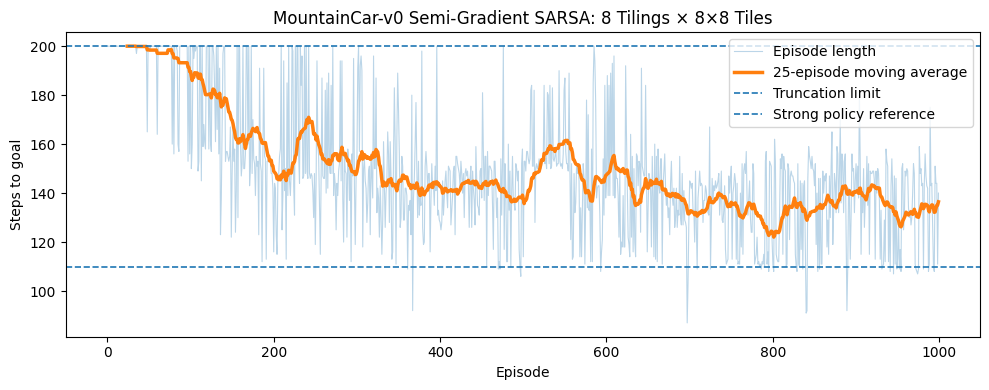

In [18]:
def moving_average(x, window=25):
    x = np.asarray(x, dtype=float)
    if len(x) < window:
        return x
    return np.convolve(x, np.ones(window) / window, mode="valid")


plt.figure(figsize=(10, 4))
plt.plot(lengths, alpha=0.30, linewidth=0.8, label="Episode length")
ma = moving_average(lengths, 25)
plt.plot(np.arange(len(ma)) + 24, ma, linewidth=2.5, label="25-episode moving average")
plt.axhline(200, linestyle="--", linewidth=1.2, label="Truncation limit")
plt.axhline(110, linestyle="--", linewidth=1.2, label="Strong policy reference")
plt.title("MountainCar-v0 Semi-Gradient SARSA: 8 Tilings × 8×8 Tiles")
plt.xlabel("Episode")
plt.ylabel("Steps to goal")
plt.legend()
plt.tight_layout()
plt.show()

## 4. Experiment with feature configurations

The next cell compares several tile coding designs:

| Configuration | Purpose |
|---|---|
| 4 tilings × 8×8 | lower cost, less generalization stability |
| 8 tilings × 6×6 | coarser tiles, more generalization |
| 8 tilings × 8×8 | baseline |
| 8 tilings × 10×10 | finer tiles, more features |
| 16 tilings × 8×8 | smoother approximation, higher cost |

Expected pattern:
- More tilings usually improve smoothness but increase computation.
- Finer grids can learn more precise policies but may need more data.
- Coarser grids learn quickly but can underfit the value function.

In [19]:
experiment_configs = [
    {"name": "4 tilings, 8x8",  "num_tilings": 4,  "tiles_per_dim": (8, 8),  "alpha": 0.3},
    {"name": "8 tilings, 6x6",  "num_tilings": 8,  "tiles_per_dim": (6, 6),  "alpha": 0.3},
    {"name": "8 tilings, 8x8",  "num_tilings": 8,  "tiles_per_dim": (8, 8),  "alpha": 0.3},
    {"name": "8 tilings, 10x10", "num_tilings": 8, "tiles_per_dim": (10, 10), "alpha": 0.3},
    {"name": "16 tilings, 8x8", "num_tilings": 16, "tiles_per_dim": (8, 8), "alpha": 0.3},
]

results = {}

for cfg in experiment_configs:
    print("Training:", cfg["name"])
    res = train_semi_gradient_sarsa(
        num_tilings=cfg["num_tilings"],
        tiles_per_dim=cfg["tiles_per_dim"],
        n_episodes=1000,
        alpha=cfg["alpha"],
        gamma=1.0,
        epsilon=0.1,
        epsilon_decay=0.995,
        epsilon_min=0.01,
        seed=123,
    )
    results[cfg["name"]] = res
    final_avg = res["episode_lengths"][-100:].mean()
    final_success = res["successes"][-100:].mean()
    n_features = res["tile_coder"].num_features
    print(f"  features={n_features:4d} | final avg={final_avg:6.1f} | success={final_success:5.1%}")

Training: 4 tilings, 8x8
  features= 256 | final avg= 145.2 | success=97.0%
Training: 8 tilings, 6x6
  features= 288 | final avg= 154.4 | success=91.0%
Training: 8 tilings, 8x8
  features= 512 | final avg= 140.8 | success=99.0%
Training: 8 tilings, 10x10
  features= 800 | final avg= 132.7 | success=100.0%
Training: 16 tilings, 8x8
  features=1024 | final avg= 124.6 | success=100.0%


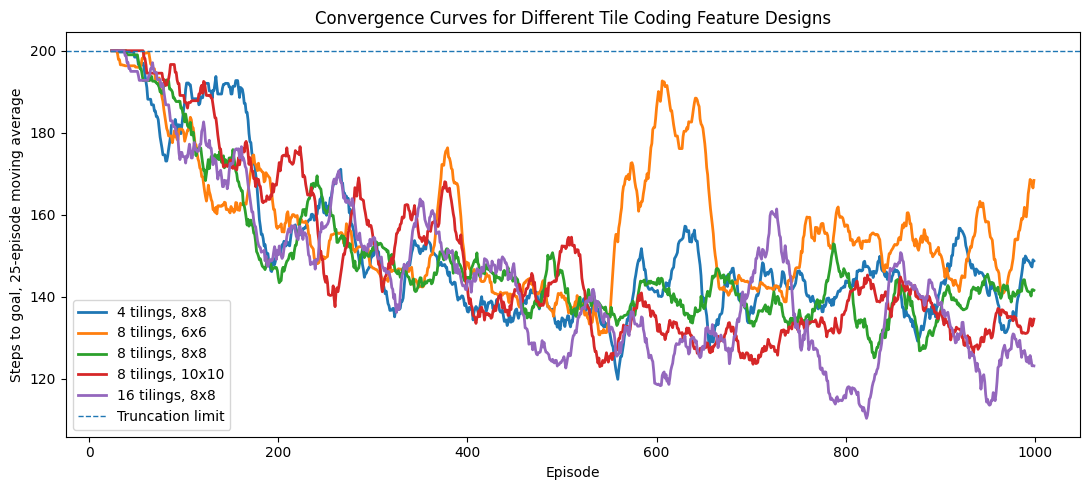

Summary:
name | tilings | tiles_per_dim | features | final_100_avg_steps | final_100_success
4 tilings, 8x8    |       4 | (8, 8)       |      256 |               145.2 | 97.0%
8 tilings, 6x6    |       8 | (6, 6)       |      288 |               154.4 | 91.0%
8 tilings, 8x8    |       8 | (8, 8)       |      512 |               140.8 | 99.0%
8 tilings, 10x10  |       8 | (10, 10)     |      800 |               132.7 | 100.0%
16 tilings, 8x8   |      16 | (8, 8)       |     1024 |               124.6 | 100.0%


In [20]:
plt.figure(figsize=(11, 5))

summary_rows = []
for name, res in results.items():
    y = moving_average(res["episode_lengths"], 25)
    plt.plot(np.arange(len(y)) + 24, y, linewidth=2, label=name)

    tc = res["tile_coder"]
    summary_rows.append([
        name,
        res["config"]["num_tilings"],
        tuple(res["config"]["tiles_per_dim"]),
        tc.num_features,
        float(res["episode_lengths"][-100:].mean()),
        float(res["successes"][-100:].mean()),
    ])

plt.axhline(200, linestyle="--", linewidth=1.0, label="Truncation limit")
plt.title("Convergence Curves for Different Tile Coding Feature Designs")
plt.xlabel("Episode")
plt.ylabel("Steps to goal, 25-episode moving average")
plt.legend()
plt.tight_layout()
plt.show()

print("Summary:")
print("name | tilings | tiles_per_dim | features | final_100_avg_steps | final_100_success")
for row in summary_rows:
    print(f"{row[0]:17s} | {row[1]:7d} | {str(row[2]):12s} | {row[3]:8d} | {row[4]:19.1f} | {row[5]:.1%}")

## 5. Learned value function and policy

The value function is evaluated on a dense position × velocity grid using `np.meshgrid`.

For each grid state:
1. compute active tiles,
2. compute Q-values for all actions,
3. store \(\max_a Q(s,a)\) as the value,
4. store `argmax_a Q(s,a)` as the learned policy.

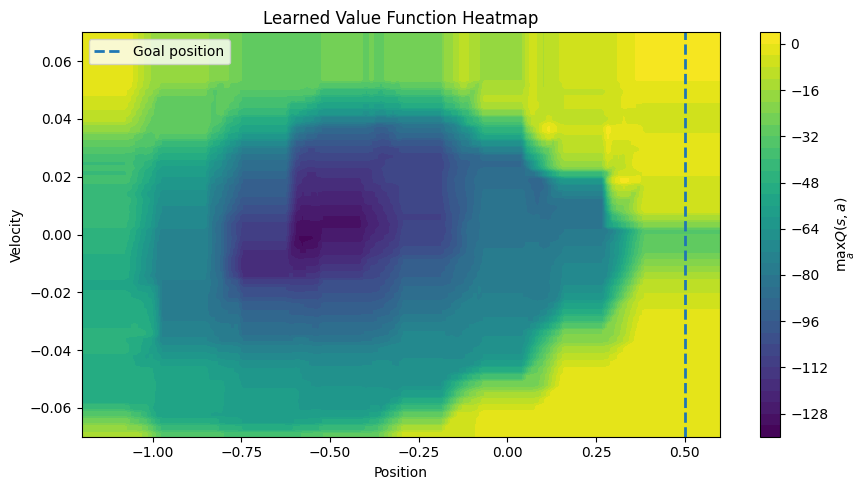

In [21]:
def evaluate_on_grid(result: Dict, n_pos: int = 120, n_vel: int = 120):
    weights = result["weights"]
    tc = result["tile_coder"]

    pos = np.linspace(tc.low[0], tc.high[0], n_pos)
    vel = np.linspace(tc.low[1], tc.high[1], n_vel)
    P, V = np.meshgrid(pos, vel)

    values = np.zeros_like(P, dtype=float)
    actions = np.zeros_like(P, dtype=int)

    for i in range(n_vel):
        for j in range(n_pos):
            state = np.array([P[i, j], V[i, j]])
            active = tc.active_tiles(state)
            qs = q_values(weights, active)
            values[i, j] = np.max(qs)
            actions[i, j] = int(np.argmax(qs))

    return P, V, values, actions


P, V, value_grid, action_grid = evaluate_on_grid(baseline)

plt.figure(figsize=(9, 5))
cf = plt.contourf(P, V, value_grid, levels=35)
plt.colorbar(cf, label=r"$\max_a Q(s,a)$")
plt.axvline(0.5, linestyle="--", linewidth=2, label="Goal position")
plt.title("Learned Value Function Heatmap")
plt.xlabel("Position")
plt.ylabel("Velocity")
plt.legend()
plt.tight_layout()
plt.show()

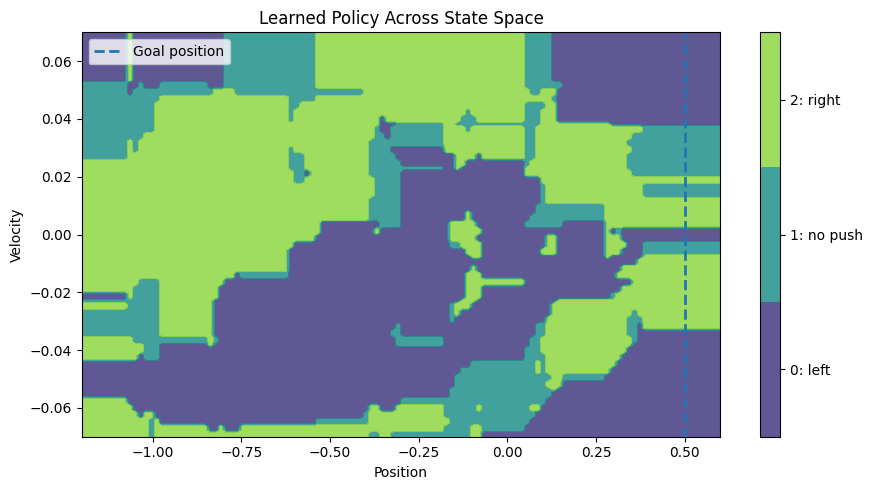

In [22]:
plt.figure(figsize=(9, 5))
policy_plot = plt.contourf(P, V, action_grid, levels=[-0.5, 0.5, 1.5, 2.5], alpha=0.85)
cbar = plt.colorbar(policy_plot, ticks=[0, 1, 2])
cbar.ax.set_yticklabels(["0: left", "1: no push", "2: right"])
plt.axvline(0.5, linestyle="--", linewidth=2, label="Goal position")
plt.title("Learned Policy Across State Space")
plt.xlabel("Position")
plt.ylabel("Velocity")
plt.legend()
plt.tight_layout()
plt.show()

## 6. Sample trajectories overlaid on the value function

The trajectories below start from different position/velocity pairs and then follow the greedy learned policy. A good MountainCar policy usually first builds momentum by moving away from the goal, then uses that stored energy to climb the right hill.

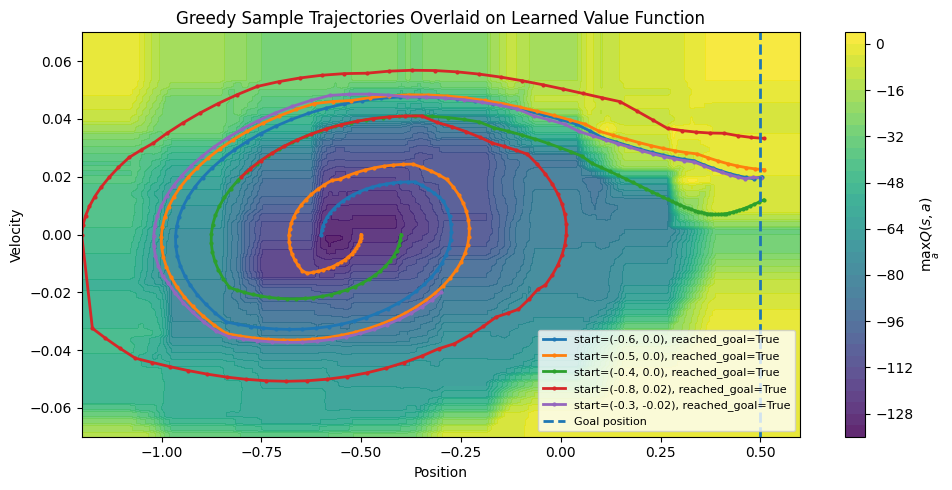

In [23]:
def greedy_action(result: Dict, state: Sequence[float]) -> int:
    active = result["tile_coder"].active_tiles(state)
    return int(np.argmax(q_values(result["weights"], active)))


def rollout_from_state(
    result: Dict,
    start_state: Tuple[float, float],
    max_steps: int = 200,
    env_name: str = "MountainCar-v0",
):
    env = gym.make(env_name)
    state, _ = env.reset(seed=0)

    # Directly set the internal state for controlled trajectory visualization.
    env.unwrapped.state = np.array(start_state, dtype=np.float64)
    state = np.array(start_state, dtype=float)

    trajectory = [state.copy()]
    terminated = False

    for _ in range(max_steps):
        action = greedy_action(result, state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        trajectory.append(next_state.copy())
        state = next_state

        if terminated or truncated:
            break

    env.close()
    return np.asarray(trajectory), terminated


start_states = [
    (-0.60, 0.00),
    (-0.50, 0.00),
    (-0.40, 0.00),
    (-0.80, 0.02),
    (-0.30, -0.02),
]

plt.figure(figsize=(10, 5))
cf = plt.contourf(P, V, value_grid, levels=35, alpha=0.85)
plt.colorbar(cf, label=r"$\max_a Q(s,a)$")

for start in start_states:
    traj, reached = rollout_from_state(baseline, start)
    label = f"start={start}, reached_goal={reached}"
    plt.plot(traj[:, 0], traj[:, 1], linewidth=2, marker="o", markersize=2, label=label)

plt.axvline(0.5, linestyle="--", linewidth=2, label="Goal position")
plt.title("Greedy Sample Trajectories Overlaid on Learned Value Function")
plt.xlabel("Position")
plt.ylabel("Velocity")
plt.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

## 7. Interpretation: how feature design affects learning

**Number of tilings.** More tilings create more overlapping features, so nearby states share information more smoothly. This often improves stability and final policy quality. The cost is larger weight matrices and more active features to update at every step. For example, 16 tilings of 8×8 tiles has twice the active features per update compared with 8 tilings of 8×8.

**Tile size.** Coarser tiles, such as 6×6, generalize strongly because many nearby states share the same features. This can speed up early learning, but the final value function may be less precise. Finer tiles, such as 10×10, represent more local detail, but they also increase the number of features and may require more episodes before every important region is learned well.

**Offsets.** Offsets are what make tile coding stronger than a single discretization grid. If all tilings had the same boundaries, the representation would behave like one grid copied several times. Staggered offsets let the agent distinguish states that would otherwise fall into the same bin in a single grid.

**Computational cost.** The feature vector size is:

\[
\text{features} = \text{num tilings} \times \prod_d \text{tiles per dimension}_d
\]

However, each state activates only `num_tilings` features. That is why sparse active indices are efficient: the update cost grows mainly with the number of tilings, not with the full feature-vector length.

**Why function approximation solves the continuous-state issue.** Instead of storing values for infinitely many states, the agent learns weights over reusable features. Similar states activate overlapping tiles, so learning from one transition improves estimates for nearby states. This generalization is exactly what tabular methods cannot do naturally in continuous spaces.

Training offset mode: diagonal
Training offset mode: random


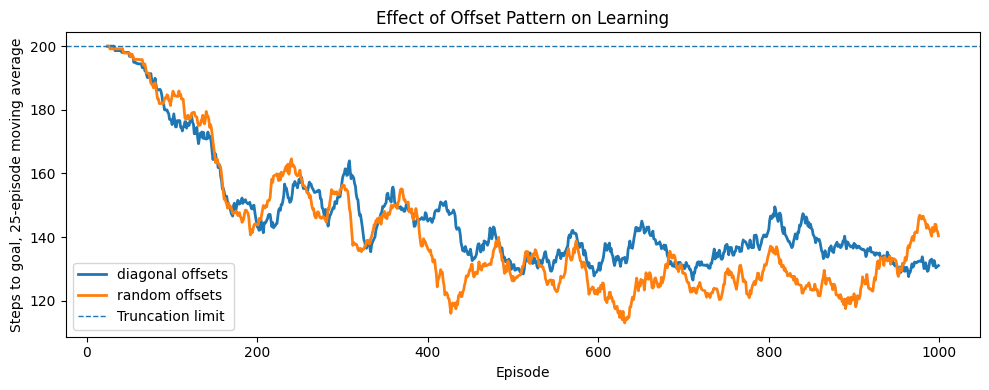

In [24]:
# Optional: compare deterministic diagonal offsets with random offsets
offset_results = {}

for offset_mode in ["diagonal", "random"]:
    print("Training offset mode:", offset_mode)
    offset_results[offset_mode] = train_semi_gradient_sarsa(
        num_tilings=8,
        tiles_per_dim=(8, 8),
        offset_mode=offset_mode,
        n_episodes=1000,
        alpha=0.3,
        gamma=1.0,
        epsilon=0.1,
        epsilon_decay=0.995,
        epsilon_min=0.01,
        seed=77,
    )

plt.figure(figsize=(10, 4))
for mode, res in offset_results.items():
    y = moving_average(res["episode_lengths"], 25)
    plt.plot(np.arange(len(y)) + 24, y, linewidth=2, label=f"{mode} offsets")

plt.axhline(200, linestyle="--", linewidth=1.0, label="Truncation limit")
plt.title("Effect of Offset Pattern on Learning")
plt.xlabel("Episode")
plt.ylabel("Steps to goal, 25-episode moving average")
plt.legend()
plt.tight_layout()
plt.show()

## 8. Final takeaway

Semi-gradient SARSA with tile coding is a practical solution for MountainCar because it combines TD learning with generalization. The agent does not memorize a table. Instead, it learns reusable weights over overlapping state-space regions. The best feature design balances smoothness, precision, and computational cost. For this task, **8 tilings of 8×8 tiles** is a strong baseline because it provides enough overlap to generalize while keeping the number of features manageable.